In [1]:
import pandas as pd
import numpy as np
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
from torchmetrics import Precision, Recall
from torchmetrics.classification import (BinaryAccuracy, 
                                         BinaryPrecision, 
                                         BinaryRecall, 
                                         BinaryF1Score, 
                                         BinaryConfusionMatrix)

In [2]:
class ECGDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path, header=None)
        features = df.iloc[:, :-1].to_numpy()
        original_labels = df.iloc[:, -1].to_numpy()
        binary_labels = (original_labels != 0).astype(np.int64)

        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(binary_labels, dtype=torch.long) # .long converts from float to a pytorch int

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        features = self.features[idx]
        features = features.unsqueeze(0)
        label = self.labels[idx]
        return features, label


In [3]:
dataset_train = ECGDataset('data/mitbih_train.csv')
dataset_test = ECGDataset('data/mitbih_test.csv')

dataloader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=16, shuffle=False)

In [4]:
class SimpleCNN1d(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten(),
        )
        self.classifier = nn.Linear(64 * 46, num_classes)
        '''
        starting shape: [batch, 1, 187]
        after first conv: [batch, 32, 187]
        after max pooling: [batch, 32, 93], the sequence length gets divided by kernel
        after second conv: [batch, 64, 93]
        after second pooling layer: [batch, 64, 46]
        after flattening [batch, 64 * 46]
        '''

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [5]:
net = SimpleCNN1d(num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for features, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    average_loss = running_loss / len(dataloader_train)
    print(f"Epoch {epoch + 1}/{num_epochs}, "f"Loss: {average_loss:.4f}")


Epoch 1/10, Loss: 0.1410
Epoch 2/10, Loss: 0.0870
Epoch 3/10, Loss: 0.0718
Epoch 4/10, Loss: 0.0637
Epoch 5/10, Loss: 0.0572
Epoch 6/10, Loss: 0.0531
Epoch 7/10, Loss: 0.0491
Epoch 8/10, Loss: 0.0459
Epoch 9/10, Loss: 0.0434
Epoch 10/10, Loss: 0.0407


In [6]:
metric_precision = Precision(task='binary')
metric_recall = Recall(task='binary')

net.eval()
with torch.no_grad():
    for features, labels in dataloader_test:
        outputs = net(features)
        preds = torch.argmax(outputs, dim=1)
        metric_precision.update(preds, labels)
        metric_recall.update(preds, labels)
precision = metric_precision.compute()
recall = metric_recall.compute()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9733
Recall: 0.9282


In [9]:
accuracy_metric = BinaryAccuracy()
precision_metric = BinaryPrecision()
recall_metric = BinaryRecall()
f1_metric = BinaryF1Score()
confusion_matrix_metric = BinaryConfusionMatrix()

net.eval()

with torch.no_grad():
    for features, labels in dataloader_test:
        outputs = net(features)
        predictions = torch.argmax(outputs, dim=1)

        accuracy_metric.update(predictions, labels)
        precision_metric.update(predictions, labels)
        recall_metric.update(predictions, labels)
        f1_metric.update(predictions, labels)
        confusion_matrix_metric.update(predictions, labels)

accuracy = accuracy_metric.compute()
precision = precision_metric.compute()
recall = recall_metric.compute()
f1 = f1_metric.compute()
confusion_matrix = confusion_matrix_metric.compute().numpy()

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
# print("\nConfusion matrix:")
# print(confusion_matrix)

Accuracy:  0.9832
Precision: 0.9733
Recall:    0.9282
F1 score:  0.9502


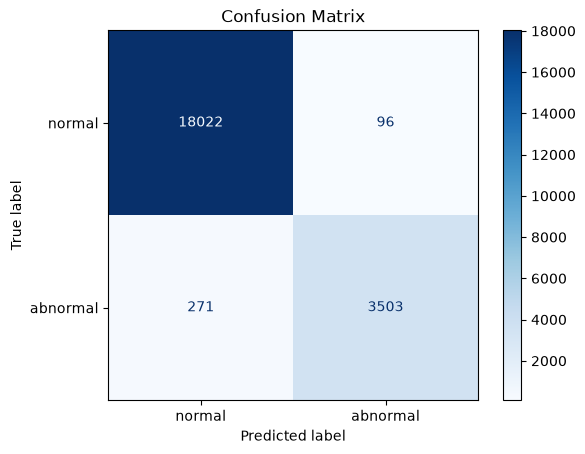

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

signal = ['normal', 'abnormal']
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=signal)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()